# 타이타닉 생존 예측

승객 정보로 생존 여부를 예측하고, 그 과정에서 확인한 것을 정리한 노트.

**핵심 결론:** 가장 단순한 결정 트리가, 더 복잡하게 만든 모델들(호칭 추가·가족 단서·랜덤포레스트)보다 실제 점수가 더 좋았다. 작고 노이즈가 큰 데이터에서는 복잡하게 만든다고 항상 좋아지지 않는다.

## 1. 준비 — 라이브러리와 데이터 불러오기

- `pandas`: 표(엑셀 같은 데이터)를 다루는 도구
- `scikit-learn`: 머신러닝 도구 상자 (결정 트리, 교차검증 등)

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import os

# 노트북을 어디서 열든 데이터 파일을 찾도록 경로를 맞춤
BASE = "titanic" if os.path.exists("titanic/train.csv") else "."
train = pd.read_csv(f"{BASE}/train.csv")   # 정답(Survived) 있는 891명
test  = pd.read_csv(f"{BASE}/test.csv")    # 정답 없는 418명 (예측 대상)
print("train:", train.shape, " / test:", test.shape)

train: (891, 12)  / test: (418, 11)


## 2. 데이터 살펴보기 — 누가 살아남았나

추측 전에 데이터에 먼저 물어본다.

In [2]:
print("전체 생존율:", round(train["Survived"].mean(), 3))
print("\n성별 생존율:")
print(train.groupby("Sex")["Survived"].mean().round(3))
train.head()

전체 생존율: 0.384

성별 생존율:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


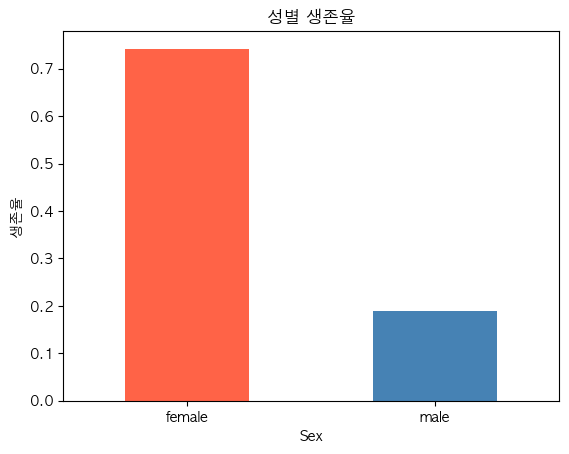

In [3]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"   # 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

train.groupby("Sex")["Survived"].mean().plot(kind="bar", color=["tomato", "steelblue"])
plt.ylabel("생존율")
plt.title("성별 생존율")
plt.xticks(rotation=0)
plt.show()

성별 생존율을 보면 여성이 압도적으로 높다. "여성·아이 먼저" 구조 때문. 가장 강력한 단서다.

## 3. 전처리 — 컴퓨터가 읽게 다듬기

원래 데이터는 12개 컬럼이다. 여기서 정답(Survived)·순번(PassengerId)을 빼고, 글자라 바로 못 쓰거나(Name, Ticket, Embarked) 빈 칸이 77%인 컬럼(Cabin)도 뺐다. 남은 6개(Pclass, Sex, Age, SibSp, Parch, Fare)가 기본 단서다.

모델은 숫자만 받고, 빈 칸이 있으면 학습을 거부한다. 그래서:

- 성별(male/female) → 숫자 (female=1, male=0)
- 나이·요금의 빈 칸 → 그 열의 중앙값으로 채우기

In [4]:
for df in [train, test]:                       # train, test 둘 다 똑같이!
    df["Sex"]  = (df["Sex"] == "female").astype(int)
    df["Age"]  = df["Age"].fillna(train["Age"].median())
    df["Fare"] = df["Fare"].fillna(train["Fare"].median())
print("전처리 완료 (성별 숫자화 + 빈 칸 메움)")

전처리 완료 (성별 숫자화 + 빈 칸 메움)


## 4. 모델 — 결정 트리 + 교차검증

- **결정 트리**: "이 단서 보고 → 저 단서 보고" 갈래를 타며 생존/사망을 판단
- **교차검증(cv=5)**: 데이터를 5조각으로 나눠 5번 시험 → 운에 덜 휘둘리는 점수
- **층화추출**: 사이킷런은 분류 모델일 때 `cv=5`를 자동으로 층화추출로 나눈다 — 매 조각의 생존/사망 비율을 원본(38%/62%)과 똑같이 맞춤 (회귀였다면 이 자동 층화는 없다)
- `max_depth=4`: 나무 깊이를 제한해 과적합 방지

In [5]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = train[features]
y = train["Survived"]

model = DecisionTreeClassifier(max_depth=4, random_state=42)
score = cross_val_score(model, X, y, cv=5)
print("교차검증 5번 점수:", score.round(3))
print("평균 정확도     :", round(score.mean(), 4))

교차검증 5번 점수: [0.76  0.826 0.809 0.787 0.843]
평균 정확도     : 0.8048


## 5. 실험 — 복잡하게 만들수록 좋아질까

기본 트리(단서 6개, 교차검증 0.8048)에 하나씩 얹어가며 비교했다.

In [6]:
# 이름에서 호칭 추출 → 흔한 4개(Mr/Mrs/Miss/Master) 빼고 나머지는 Rare로 묶기
train["Title"] = train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
titles = ["Mr", "Mrs", "Miss", "Master", "Rare"]
train.loc[~train["Title"].isin(titles), "Title"] = "Rare"
for t in titles:
    train["Title_" + t] = (train["Title"] == t).astype(int)

features_title = features + ["Title_" + t for t in titles]
score_title = cross_val_score(model, train[features_title], y, cv=5)
print("+ 호칭 원-핫(11개) 평균:", round(score_title.mean(), 4))

+ 호칭 원-핫(11개) 평균: 0.826


교차검증은 0.8048 → 0.826으로 올랐다. 그런데 실제 캐글 제출 점수는 0.780 → 0.761로 떨어졌다. 단서를 늘렸는데 실전에선 더 나빠졌다.

In [7]:
# 가족 크기 = 형제자매/배우자(SibSp) + 부모자식(Parch) + 본인 1명
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

def family_group(n):
    if n == 1:   return "alone"
    elif n <= 4: return "small"
    else:        return "large"

train["FamGroup"] = train["FamilySize"].apply(family_group)
for g in ["alone", "small", "large"]:
    train["Fam_" + g] = (train["FamGroup"] == g).astype(int)

features_fam = features + ["Fam_alone", "Fam_small", "Fam_large"]
score_fam = cross_val_score(model, train[features_fam], y, cv=5)
print("+ 가족그룹(9개) 평균:", round(score_fam.mean(), 4))

+ 가족그룹(9개) 평균: 0.8126


검증 0.813, 실제 0.768 — 역시 기본 트리(0.780)를 못 넘었다. 집계로는 작은 가족(2~4명)이 제일 유리했지만, 단서로 넣는다고 실전 점수가 오르진 않았다.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# 단서는 기본 6개 그대로, 모델만 나무 100그루짜리 깊은 숲으로
forest = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
score_forest = cross_val_score(forest, X, y, cv=5)
print("깊은 랜덤포레스트(단서 6개 그대로) 평균:", round(score_forest.mean(), 4))

깊은 랜덤포레스트(단서 6개 그대로) 평균: 0.8294


단서는 그대로 두고 모델만 나무 100그루짜리 숲으로 바꿨다. 검증 0.829로 넷 중 가장 높았는데, 실제는 0.775로 역시 기본 트리를 넘지 못했다.

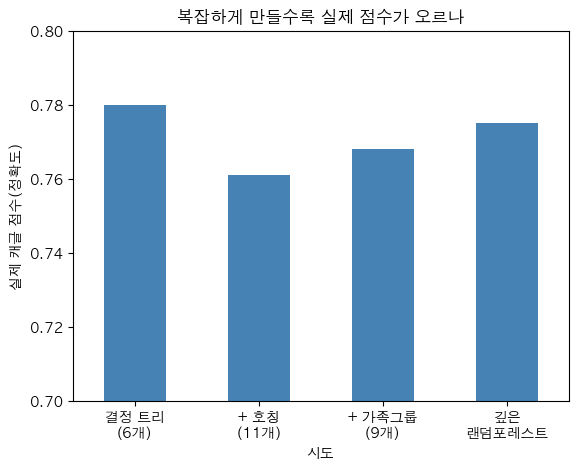

In [9]:
# 네 조건의 실제 캐글 점수 (교차검증이 아니라 실제 제출로 받은 점수)
results = pd.DataFrame({
    "시도": ["결정 트리\n(6개)", "+ 호칭\n(11개)", "+ 가족그룹\n(9개)", "깊은\n랜덤포레스트"],
    "실제 캐글 점수": [0.780, 0.761, 0.768, 0.775],
})
results.plot(x="시도", y="실제 캐글 점수", kind="bar", legend=False, color="steelblue")
plt.ylabel("실제 캐글 점수(정확도)")
plt.ylim(0.7, 0.8)
plt.title("복잡하게 만들수록 실제 점수가 오르나")
plt.xticks(rotation=0)
plt.show()

### 배운 것

1. 작고 노이즈 큰 데이터에선 복잡함이 더 낫지 않다. 단서·모델을 늘려도 실전 점수는 오히려 내려갔다.
2. 교차검증은 믿되 한계도 있다. 데이터가 작으면 교차검증조차 과장될 수 있고, 0.01 정도 차이는 노이즈다.
3. 추측보다 데이터. 가족 크기 효과는 짐작 대신 크기별 생존율 집계로 확인했다(작은 가족 2~4명이 가장 유리).

## 6. 최종 예측 → 제출 파일

교차검증이 끝났으니 891명 전부로 최종 학습 → test 418명 예측 → 제출 파일 저장.

In [10]:
model.fit(X, y)                                    # 891명 전부로 학습
test["Survived"] = model.predict(test[features])   # 418명 예측

submission = test[["PassengerId", "Survived"]]
submission.to_csv(f"{BASE}/submission_notebook.csv", index=False)
print("submission_notebook.csv 저장 완료! (418명)")
submission.head()

submission_notebook.csv 저장 완료! (418명)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


방금 최종 학습한 트리가 실제로 어떻게 갈래를 타는지 보면 이렇다.

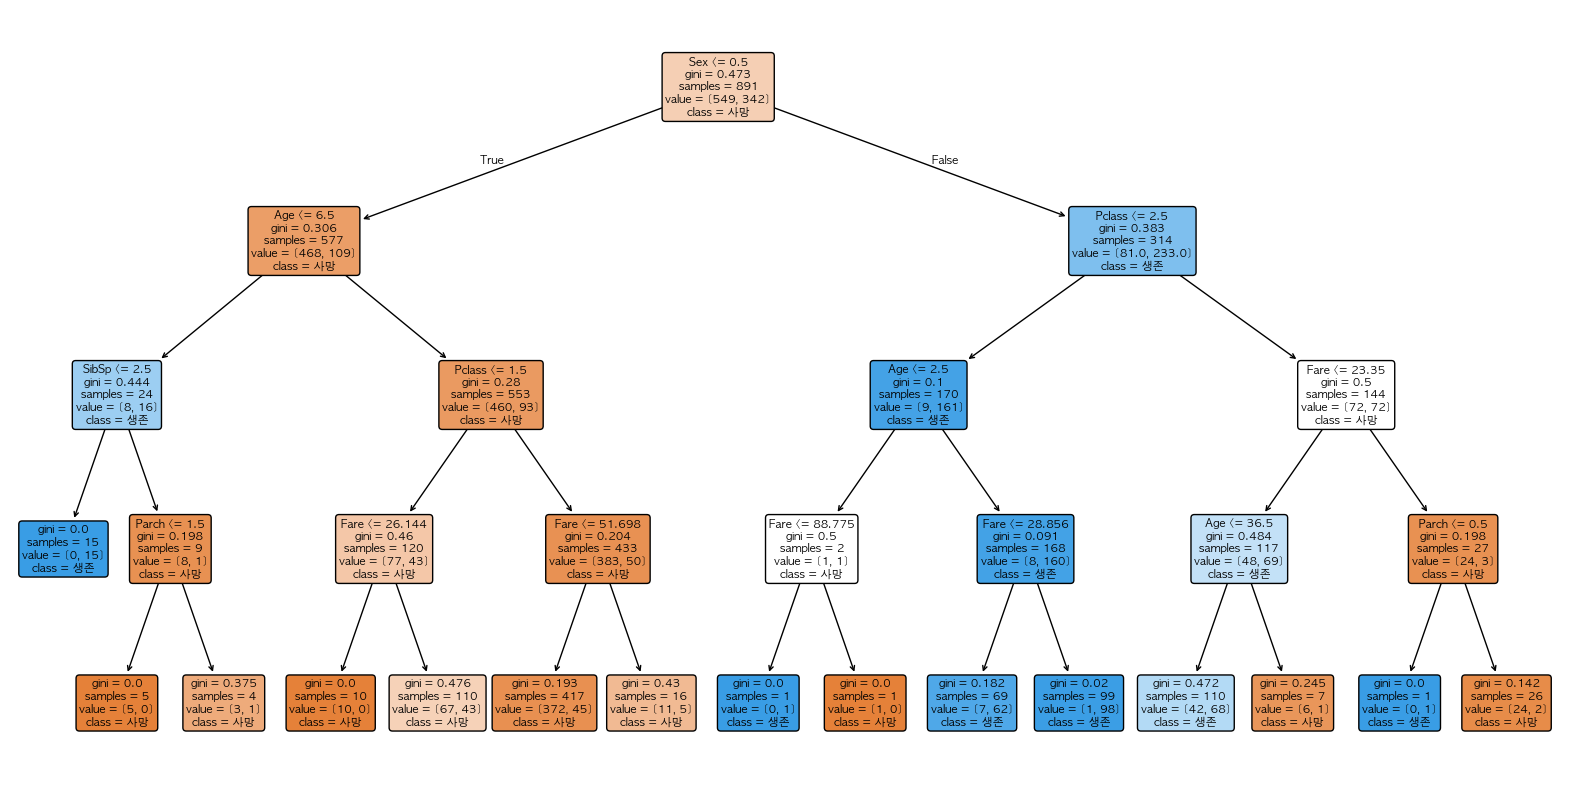

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=features, class_names=["사망", "생존"],
          filled=True, rounded=True, fontsize=8)
plt.show()

## 7. 파이프라인 — 전처리를 언제 계산하느냐

3번에서 나이 빈칸을 train 전체의 중앙값으로 채우고 교차검증을 돌렸다. 그런데 순서가 이상하다. 교차검증은 5조각 중 1조각을 "시험지"로 숨기는데, 나누기 **전에** 이미 전체 중앙값으로 빈칸을 채웠다. 그럼 숨겨야 할 시험지 조각의 나이 값도 그 중앙값 계산에 들어가 있다.

`[20, NaN, 30, 40, 100]`에서 100살이 시험지로 빠졌다고 하면:

- 전체로 계산한 중앙값 = 35
- 훈련 4명만으로 계산 = 30

같은 빈칸에 다른 값이 채워진다. 시험지 쪽에만 있어야 할 100살이 훈련 데이터 전처리에 영향을 준 것 — **데이터 누수(data leakage)**다.

교차검증을 안 쓰면 필요없나? 반은 그렇다. 아예 안 나누고 train 전체로 학습해 test만 예측하면 누수가 없다. 하지만 모델을 다듬으려면(하이퍼파라미터 조정, 성능 확인) 결국 나누게 되고, 그때마다 손으로 "제대로 나눠서 채웠나"를 챙겨야 한다. 위 코드는 안 챙겼다.

**파이프라인**은 전처리와 모델을 하나로 묶어, 교차검증 매 라운드마다 "훈련 조각에서만 중앙값 계산 → 그 값으로 시험 조각도 채우기"를 자동으로 다시 한다. 위 실수가 구조적으로 불가능해진다.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 원본을 다시 불러온다 (결측치를 미리 채우지 않고, 그 일을 파이프라인에 맡기기 위해)
# 성별은 결측치가 없는 열이라 미리 숫자화해도 누수와 무관 — 그대로 둠
train_raw = pd.read_csv(f"{BASE}/train.csv")
train_raw["Sex"] = (train_raw["Sex"] == "female").astype(int)

X_raw = train_raw[features]   # Age에 결측치가 아직 남아있는 상태
y = train_raw["Survived"]

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # 매 교차검증 라운드마다 "훈련 조각"의 중앙값만으로 계산됨
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

score_pipe = cross_val_score(pipe, X_raw, y, cv=5)
print("파이프라인 교차검증 5번 점수:", score_pipe.round(3))
print("평균 정확도             :", round(score_pipe.mean(), 4))
print("(기존 방식 평균 0.8048과 비교)")

파이프라인 교차검증 5번 점수: [0.76  0.826 0.809 0.787 0.843]
평균 정확도             : 0.8048
(기존 방식 평균 0.8048과 비교)


### 돌려보니

돌리기 전 예측: 누수가 있었으니 점수가 조금은 바뀌겠지.

결과: **0.8048.** 소수점 4자리까지, 폴드별 점수 `[0.76, 0.826, 0.809, 0.787, 0.843]`까지 기존 방식과 완전히 똑같았다.

교차검증 점수가 같다는 건 "점수 추정치가 같다"는 것일 뿐, 실제 제출 결과가 같다는 증거는 아니다. 그래서 한 단계 더 확인했다: 파이프라인으로 891명 전부를 최종 학습시켜 만든 test 418명 예측값과, 기존(수동) 방식으로 만든 예측값을 하나하나 비교했다 — **418개 전부 완전히 동일했다.**

이유는 당연했다. 누수는 교차검증이 5조각 중 1조각을 "시험지"로 숨기는 그 순간에만 생기는 문제다. 그런데 최종 제출 모델은 891명 전부로 학습하지, 조각을 숨기지 않는다. test 418명의 빈 칸도 원래부터 train의 중앙값으로만 채웠다(test 값을 섞어 쓴 적이 없다). 즉 **최종 제출 단계는 애초에 누수 구조가 아니었다** — 누수는 오직 "교차검증 점수를 얼마나 믿을 수 있는가"에만 영향을 줄 수 있는 문제였지, 실제 제출 결과에는 영향을 줄 수 없는 구조였다.

그래도 파이프라인을 기본으로 쓰는 이유는 남아있다: ① 평균·표준편차로 스케일링하는 것처럼 통계가 민감하거나 데이터가 더 작으면 최종 모델 단계에서도 차이가 실제로 벌어질 수 있다. ② 손으로 챙기다 틀리는 걸 구조적으로 막아준다.

## 8. 마무리

이 노트북의 모델(결정 트리, 단서 6개)과 같은 조건의 제출이 실제 캐글에서 받은 점수는 정확도 0.7799다. 호칭·가족그룹·랜덤포레스트로 단서와 모델을 늘린 세 번의 시도 모두 이 점수를 넘지 못했다(0.761 / 0.768 / 0.775).

작고 노이즈가 큰 데이터에서는 단서와 모델을 늘리는 것이 항상 실전 점수로 이어지지 않는다. 교차검증은 유용한 나침반이지만 작은 데이터에서는 그 나침반도 과장될 수 있다 — 실제로 확인하기 전까지는 검증 점수만으로 판단하지 않는다.